## 1. Install and Import the Required Libraries

In [ ]:
# Install all the required libraries
!pip install -U -q pdfplumber tiktoken openai chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.1/267.1 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.5/525.5 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 32.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# Import all the required Libraries

import pdfplumber
from pathlib import Path
import pandas as pd
from operator import itemgetter
import json
import tiktoken
import openai
import chromadb

## 2. Read, Process, and Chunk the PDF Files

We will be using [pdfplumber](https://https://pypi.org/project/pdfplumber/) to read and process the PDF files.

`pdfplumber` allows for better parsing of the PDF file as it can read various elements of the PDF apart from the plain text, such as, tables, images, etc. It also offers wide functionaties and visual debugging features to help with advanced preprocessing as well.

In [3]:
# Define the path of the PDF
single_pdf_path = './data/raw/Principal-Sample-Life-Insurance-Policy.pdf'

#### <font color = red>  2.1 Reading a single PDF file and exploring it through pdfplumber

In [4]:
# Open the PDF file
with pdfplumber.open(single_pdf_path) as pdf:

    # Get one of the pages from the PDF and examine it
    single_page = pdf.pages[6]

    # Extract text from the first page
    text = single_page.extract_text()

    # Extract tables from the first page
    tables = single_page.extract_tables()

    # Print the extracted text
    print(text)

Section A – Eligibility
Member Life Insurance Article 1
Member Accidental Death and Dismemberment Insurance Article 2
Dependent Life Insurance Article 3
Section B - Effective Dates
Member Life Insurance Article 1
Member Accidental Death and Dismemberment Insurance Article 2
Dependent Life Insurance Article 3
Section C - Individual Terminations
Member Life Insurance Article 1
Member Accidental Death and Dismemberment Insurance Article 2
Dependent Life Insurance Article 3
Termination for Fraud Article 4
Coverage While Outside of the United States Article 5
Section D - Continuation
Member Life Insurance Article 1
Dependent Insurance - Developmentally Disabled or
Physically Handicapped Children Article 2
Section E - Reinstatement
Reinstatement Article 1
Federal Required Family and Medical Leave Act (FMLA) Article 2
Reinstatement of Coverage for a Member or Dependent When
Coverage Ends due to Living Outside of the United States Article 3
Section F - Individual Purchase Rights
Member Life In

In [5]:
# View the table in the page, if any

tables[0]

IndexError: list index out of range

#### 2.2 Extracting text from multiple PDFs

Let's now try and read multiple documents, extract text from them using appropriate preprocessing, and store them in a dataframe


In [7]:
# Define the path where all pdf documents are present

pdf_path = "./data/raw/"

In [8]:
# Function to check whether a word is present in a table or not for segregation of regular text and tables

def check_bboxes(word, table_bbox):
    # Check whether word is inside a table bbox.
    l = word['x0'], word['top'], word['x1'], word['bottom']
    r = table_bbox
    return l[0] > r[0] and l[1] > r[1] and l[2] < r[2] and l[3] < r[3]

In [9]:
# Function to extract text from a PDF file.
# 1. Declare a variable p to store the iteration of the loop that will help us store page numbers alongside the text
# 2. Declare an empty list 'full_text' to store all the text files
# 3. Use pdfplumber to open the pdf pages one by one
# 4. Find the tables and their locations in the page
# 5. Extract the text from the tables in the variable 'tables'
# 6. Extract the regular words by calling the function check_bboxes() and checking whether words are present in the table or not
# 7. Use the cluster_objects utility to cluster non-table and table words together so that they retain the same chronology as in the original PDF
# 8. Declare an empty list 'lines' to store the page text
# 9. If a text element in present in the cluster, append it to 'lines', else if a table element is present, append the table
# 10. Append the page number and all lines to full_text, and increment 'p'
# 11. When the function has iterated over all pages, return the 'full_text' list

def extract_text_from_pdf(pdf_path):
    p = 0
    full_text = []


    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_no = f"Page {p+1}"
            text = page.extract_text()

            tables = page.find_tables()
            table_bboxes = [i.bbox for i in tables]
            tables = [{'table': i.extract(), 'top': i.bbox[1]} for i in tables]
            non_table_words = [word for word in page.extract_words() if not any(
                [check_bboxes(word, table_bbox) for table_bbox in table_bboxes])]
            lines = []

            for cluster in pdfplumber.utils.cluster_objects(non_table_words + tables, itemgetter('top'), tolerance=5):

                if 'text' in cluster[0]:
                    try:
                        lines.append(' '.join([i['text'] for i in cluster]))
                    except KeyError:
                        pass

                elif 'table' in cluster[0]:
                    lines.append(json.dumps(cluster[0]['table']))


            full_text.append([page_no, " ".join(lines)])
            p +=1

    return full_text

*Now that we have defined the function for extracting the text and tables from a PDF, let's iterate and call this function for all the PDFs in our drive and store them in a list.*

In [10]:
# Define the directory containing the PDF files
pdf_directory = Path(pdf_path)

# Initialize an empty list to store the extracted texts and document names
data = []

# Loop through all files in the directory
for pdf_path in pdf_directory.glob("*.pdf"):

    # Process the PDF file
    print(f"...Processing {pdf_path.name}")

    # Call the function to extract the text from the PDF
    extracted_text = extract_text_from_pdf(pdf_path)

    # Convert the extracted list to a PDF, and add a column to store document names
    extracted_text_df = pd.DataFrame(extracted_text, columns=['Page No.', 'Page_Text'])
    extracted_text_df['Document Name'] = pdf_path.name

    # Append the extracted text and document name to the list
    data.append(extracted_text_df)

    # Print a message to indicate progress
    print(f"Finished processing {pdf_path.name}")

# Print a message to indicate all PDFs have been processed
print("All PDFs have been processed.")

...Processing Principal-Sample-Life-Insurance-Policy.pdf
Finished processing Principal-Sample-Life-Insurance-Policy.pdf
All PDFs have been processed.


In [11]:
# Concatenate all the DFs in the list 'data' together

insurance_pdfs_data = pd.concat(data, ignore_index=True)

In [12]:
insurance_pdfs_data

,Page No.,Page_Text,Document Name
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf
...,...,...,...
59,Page 60,I f a Dependent who was insured dies during th...,Principal-Sample-Life-Insurance-Policy.pdf
60,Page 61,Section D - Claim Procedures Article 1 - Notic...,Principal-Sample-Life-Insurance-Policy.pdf
61,Page 62,A claimant may request an appeal of a claim de...,Principal-Sample-Life-Insurance-Policy.pdf
62,Page 63,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf


In [ ]:
# Check one of the extracted page texts to ensure that the text has been correctly read

insurance_pdfs_data.Page_Text[2]

'HDFC Standard Life Insurance Company Limited HDFC SurgiCare Plan [["SCHEDULE OF BENEFITS", null, null], ["", null, null], ["Benefit(s)", "Initial Sum\\nAssured\\n(Rs)", "Expiry/Maturity Date\\n(dd/mm/yyyy)"], ["Surgical Benefit", "2,00,000", "01/01/2029"], ["Hospitalisation Cash Benefit", "2,00,000", "01/01/2029"], ["Initial Sum Assured will escalate by 5% per annum (simple addition) each year. This\\nescalated Sum Assured will be known as Annual Sum Assured. The escalation is capped at\\n50% of the initial Sum Assured. The benefits are described in Provision 3.", null, null]] SPECIFIC EXCLUSION “This policy permanently excludes any claims with respect to treatment whether directly or indirectly caused by, or attributable to ____________________________or its complications” [["NOMINATION SCHEDULE\\nEffective Date: 01/01/2009"], ["Name: Pradip Rathod\\nDate of Birth: 22/01/1986\\nPercentage: 100\\nAddress: 8B Laxmi Building, Dadar,\\nMumbai \\u2013 400038, Maharashtra"], ["DETAILS OF A

In [13]:
# Let's also check the length of all the texts as there might be some empty pages or pages with very few words that we can drop

insurance_pdfs_data['Text_Length'] = insurance_pdfs_data['Page_Text'].apply(lambda x: len(x.split(' ')))

In [14]:
insurance_pdfs_data['Text_Length']

0      30
1       5
2     230
3       5
4     110
     ... 
59    285
60    418
61    322
62      5
63      8
Name: Text_Length, Length: 64, dtype: int64

In [15]:
# Retain only the rows with a text length of at least 10

insurance_pdfs_data = insurance_pdfs_data.loc[insurance_pdfs_data['Text_Length'] >= 10]
insurance_pdfs_data

,Page No.,Page_Text,Document Name,Text_Length
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf,30
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf,230
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf,110
5,Page 6,TABLE OF CONTENTS PART I - DEFINITIONS PART II...,Principal-Sample-Life-Insurance-Policy.pdf,153
6,Page 7,Section A – Eligibility Member Life Insurance ...,Principal-Sample-Life-Insurance-Policy.pdf,176
7,Page 8,Section A - Member Life Insurance Schedule of ...,Principal-Sample-Life-Insurance-Policy.pdf,171
8,Page 9,P ART I - DEFINITIONS When used in this Group ...,Principal-Sample-Life-Insurance-Policy.pdf,387
9,Page 10,T he legally recognized union of two eligible ...,Principal-Sample-Life-Insurance-Policy.pdf,251
10,Page 11,(2) has been placed with the Member or spouse ...,Principal-Sample-Life-Insurance-Policy.pdf,299
11,Page 12,An institution that is licensed as a Hospital ...,Principal-Sample-Life-Insurance-Policy.pdf,352


In [151]:
# Store the metadata for each page in a separate column

insurance_pdfs_data['Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)

In [152]:
insurance_pdfs_data_sorted = insurance_pdfs_data.sort_values(by='Text_Length', ascending=False)
insurance_pdfs_data_sorted 

,Page No.,Page_Text,Document Name,Text_Length,Metadata
29,Page 30,"(6) If, on the date a Member becomes eligible ...",Principal-Sample-Life-Insurance-Policy.pdf,462,{'Policy_Name': 'Principal-Sample-Life-Insuran...
32,Page 33,a . In no event will Dependent Life Insurance ...,Principal-Sample-Life-Insurance-Policy.pdf,460,{'Policy_Name': 'Principal-Sample-Life-Insuran...
30,Page 31,Scheduled Benefit in force for the Member befo...,Principal-Sample-Life-Insurance-Policy.pdf,449,{'Policy_Name': 'Principal-Sample-Life-Insuran...
31,Page 32,(1) marriage or establishment of a Civil Union...,Principal-Sample-Life-Insurance-Policy.pdf,429,{'Policy_Name': 'Principal-Sample-Life-Insuran...
47,Page 48,c . If a beneficiary dies at the same time or ...,Principal-Sample-Life-Insurance-Policy.pdf,420,{'Policy_Name': 'Principal-Sample-Life-Insuran...
60,Page 61,Section D - Claim Procedures Article 1 - Notic...,Principal-Sample-Life-Insurance-Policy.pdf,418,{'Policy_Name': 'Principal-Sample-Life-Insuran...
49,Page 50,The Principal may require that a ADL Disabled ...,Principal-Sample-Life-Insurance-Policy.pdf,414,{'Policy_Name': 'Principal-Sample-Life-Insuran...
28,Page 29,Insurance for which Proof of Good Health is re...,Principal-Sample-Life-Insurance-Policy.pdf,408,{'Policy_Name': 'Principal-Sample-Life-Insuran...
42,Page 43,Any individual policy issued will then be in f...,Principal-Sample-Life-Insurance-Policy.pdf,392,{'Policy_Name': 'Principal-Sample-Life-Insuran...
46,Page 47,"M ember's death, the Death Benefits Payable ma...",Principal-Sample-Life-Insurance-Policy.pdf,391,{'Policy_Name': 'Principal-Sample-Life-Insuran...


This concludes the chunking aspect also, as we can see that mostly the pages contain few hundred words, maximum going upto 460. So, we don't need to chunk the documents further; we can perform the embeddings on individual pages. This strategy makes sense for 2 reasons:
1. The way insurance documents are generally structured, you will not have a lot of extraneous information in a page, and all the text pieces in that page will likely be interrelated.
2. We want to have larger chunk sizes to be able to pass appropriate context to the LLM during the generation layer.


## 3. Generate and Store Embeddings using OpenAI and ChromaDB

In this section, we will embed the pages in the dataframe through OpenAI's `text-embedding-ada-002` model, and store them in a ChromaDB collection.

In [31]:
# Set the API key
filepath = "../6.ShopAssist_ Data + Demo/"

with open(filepath + "openai_key.txt", "r") as f:
  openai.api_key = ' '.join(f.readlines())

In [32]:
# Import the OpenAI Embedding Function into chroma

from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

In [33]:
# Define the path where chroma collections will be stored

chroma_data_path = './ChromaDB_Data'

In [34]:
import chromadb

In [35]:
# Call PersistentClient()

client = chromadb.PersistentClient()

In [36]:
# Set up the embedding function using the OpenAI embedding model

model = "text-embedding-ada-002"
embedding_function = OpenAIEmbeddingFunction(api_key=openai.api_key, model_name=model)

In [37]:
# Initialise a collection in chroma and pass the embedding_function to it so that it used OpenAI embeddings to embed the documents

insurance_collection = client.get_or_create_collection(name='RAG_on_Insurance', embedding_function=embedding_function)

In [38]:
# Convert the page text and metadata from your dataframe to lists to be able to pass it to chroma

documents_list = insurance_pdfs_data["Page_Text"].tolist()
metadata_list = insurance_pdfs_data['Metadata'].tolist()

In [39]:
# Add the documents and metadata to the collection alongwith generic integer IDs. You can also feed the metadata information as IDs by combining the policy name and page no.

insurance_collection.add(
    documents= documents_list,
    ids = [str(i) for i in range(0, len(documents_list))],
    metadatas = metadata_list
)

In [40]:
# Let's take a look at the first few entries in the collection

insurance_collection.get(
    ids = ['0','1','2'],
    include = ['embeddings', 'documents', 'metadatas']
)

{'ids': ['0', '1', '2'],
 'embeddings': array([[-2.24758554e-02,  1.86929200e-02, -2.71849595e-02, ...,
         -3.69423255e-02,  2.88611907e-03, -1.39984931e-03],
        [-1.31909009e-02,  8.90368689e-03, -4.63019125e-03, ...,
         -1.56260375e-02, -2.96085727e-05,  7.26425555e-03],
        [-1.21258916e-02,  1.41026508e-02, -3.38967773e-03, ...,
         -2.84971725e-02, -9.47252382e-03,  1.02420002e-02]],
       shape=(3, 1536)),
 'documents': ['DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/01/2014 711 HIGH STREET GEORGE RI 02903 GROUP POLICY FOR: RHODE ISLAND JOHN DOE ALL MEMBERS Group Member Life Insurance Print Date: 07/16/2014',
  'POLICY RIDER GROUP INSURANCE POLICY NO: S655 COVERAGE: Life EMPLOYER: RHODE ISLAND JOHN DOE Effective on the later of the Date of Issue of this Group Policy or March 1, 2005, the following will apply to your Policy: From time to time The Principal may offer or provide certain employer groups who apply for coverage with The Principal a Financial 

In [41]:
cache_collection = client.get_or_create_collection(name='Insurance_Cache', embedding_function=embedding_function)

In [42]:
cache_collection.peek()

{'ids': [],
 'embeddings': array([], dtype=float64),
 'documents': [],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': []}

## 4. Semantic Search with Cache

In this section, we will perform a semantic search of a query in the collections embeddings to get several top semantically similar results.

In [126]:
# Read the user query

query = input()

 What is the scheduled Member Life Insurance benefit for all members?


In [128]:
cache_results

{'ids': [['When does this group policy terminate due to non-payment of premium?']],
 'embeddings': None,
 'documents': [['When does this group policy terminate due to non-payment of premium?']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'ids2': '33',
    'distances5': '0.3095416724681854',
    'ids1': '21',
    'ids6': '14',
    'metadatas7': "{'Page_No.': 'Page 27', 'Policy_Name': 'Principal-Sample-Life-Insurance-Policy'}",
    'distances4': '0.3000076711177826',
    'distances0': '0.20498530566692352',
    'metadatas5': "{'Page_No.': 'Page 35', 'Policy_Name': 'Principal-Sample-Life-Insurance-Policy'}",
    'documents6': "a. be actively engaged in business for profit within the meaning of the Internal Revenue Code, or be established as a legitimate nonprofit corporation within the meaning of the Internal Revenue Code; and b. make at least the level of premium contributions required for insurance on its eligible Members. The Po

In [129]:
results = insurance_collection.query(
query_texts=query,
n_results=10
)
from pprint import pprint
# The pretty-print way
pprint(results.items(), indent=4, width=40)


dict_items([('ids', [['43', '56', '5', '29', '50', '18', '51', '28', '23', '32']]), ('embeddings', None), ('documents', [["PART IV - BENEFITS Section A - Member Life Insurance Article 1 - Schedule of Insurance Subject to the Effective Date provisions of PART III, Section B, and the qualifying provisions of this Section A, the Scheduled Benefit for an insured Member will be based on his or her class: Class *Scheduled Benefit ALL MEMBERS $10,000 However, if a Member has received any payments under the Accelerated Benefits provision as described in Section A, Article 7, the Scheduled Benefit will be reduced by the amount of such payment. *The Scheduled Benefit is subject to the Proof of Good Health requirements as shown in PART III, Section B, Article 1. Because of the Proof of Good Health requirements, the amount of insurance approved by The Principal may be different than the Scheduled Benefit. If the approved amount of insurance is different than the Scheduled Benefit, the approved amo

In [130]:
# Searh the Cache collection first
# Query the collection against the user query and return the top 20 results

cache_results = cache_collection.query(
    query_texts=query,
    n_results=1
)

In [131]:
# Implementing Cache in Semantic Search

# Set a threshold for cache search
threshold = 0.2

ids = []
documents = []
distances = []
metadatas = []
results_df = pd.DataFrame()

result_count = len(results["documents"][0]) -1

# If the distance is greater than the threshold, then return the results from the main collection.

if cache_results['distances'][0] == [] or cache_results['distances'][0][0] > threshold:
      # Query the collection against the user query and return the top 10 results
      results = insurance_collection.query(
      query_texts=query,
      n_results=result_count
      )

      # Store the query in cache_collection as document w.r.t to ChromaDB so that it can be embedded and searched against later
      # Store retrieved text, ids, distances and metadatas in cache_collection as metadatas, so that they can be fetched easily if a query indeed matches to a query in cache
      Keys = []
      Values = []

      for key, val in results.items():
        if val is None:
          continue
        for i in range(result_count):
          Keys.append(str(key)+str(i))
          Values.append(str(val[0][i]))


      cache_collection.add(
          documents= [query],
          ids = [query],  # Or if you want to assign integers as IDs 0,1,2,.., then you can use "len(cache_results['documents'])" as will return the no. of queries currently in the cache and assign the next digit to the new query."
          metadatas = dict(zip(Keys, Values))
      )

      print("Not found in cache. Found in main collection.")

      result_dict = {'Metadatas': results['metadatas'][0], 'Documents': results['documents'][0], 'Distances': results['distances'][0], "IDs":results["ids"][0]}
      results_df = pd.DataFrame.from_dict(result_dict)
      results_df


# If the distance is, however, less than the threshold, you can return the results from cache

elif cache_results['distances'][0][0] <= threshold:
      cache_result_dict = cache_results['metadatas'][0][0]

      # Loop through each inner list and then through the dictionary
      for key, value in cache_result_dict.items():
          if 'ids' in key:
              ids.append(value)
          elif 'documents' in key:
              documents.append(value)
          elif 'distances' in key:
              distances.append(value)
          elif 'metadatas' in key:
              metadatas.append(value)

      print("Found in cache!")

      # Create a DataFrame
      results_df = pd.DataFrame({
        'IDs': ids,
        'Documents': documents,
        'Distances': distances,
        'Metadatas': metadatas
      })


Not found in cache. Found in main collection.


In [132]:
results_df

,Metadatas,Documents,Distances,IDs
0,"{'Page_No.': 'Page 46', 'Policy_Name': 'Princi...",PART IV - BENEFITS Section A - Member Life Ins...,0.214739,43
1,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section C - Dependent Life Insurance Article 1...,0.246433,56
2,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section A - Member Life Insurance Schedule of ...,0.254867,5
3,{'Policy_Name': 'Principal-Sample-Life-Insuran...,(1) marriage or establishment of a Civil Union...,0.264602,29
4,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section B - Member Accidental Death and Dismem...,0.264842,50
5,{'Policy_Name': 'Principal-Sample-Life-Insuran...,b . on any date the definition of Member or De...,0.295206,18
6,"{'Page_No.': 'Page 54', 'Policy_Name': 'Princi...","f . claim requirements listed in PART IV, Sect...",0.296887,51
7,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Scheduled Benefit in force for the Member befo...,0.299255,28
8,{'Policy_Name': 'Principal-Sample-Life-Insuran...,PART III - INDIVIDUAL REQUIREMENTS AND RIGHTS ...,0.303019,23


## 5. <font color = red> Re-Ranking with a Cross Encoder

Re-ranking the results obtained from your semantic search can sometime significantly improve the relevance of the retrieved results. This is often done by passing the query paired with each of the retrieved responses into a cross-encoder to score the relevance of the response w.r.t. the query.

<br>

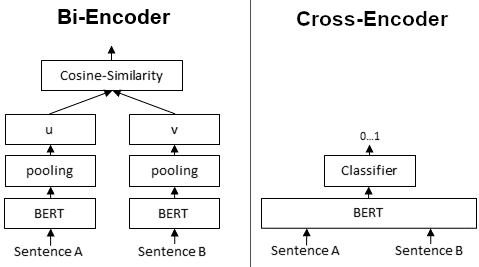

<br>

In [133]:
# Import the CrossEncoder library from sentence_transformers

from sentence_transformers import CrossEncoder, util

In [134]:
# Initialise the cross encoder model

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

Loading weights: 100%|██████████████████████| 105/105 [00:00<00:00, 7505.78it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [135]:
# Test the cross encoder model

scores = cross_encoder.predict([['Does the insurance cover diabetic patients?', 'The insurance policy covers some pre-existing conditions including diabetes, heart diseases, etc. The policy does not howev'],
                                ['Does the insurance cover diabetic patients?', 'The premium rates for various age groups are given as follows. Age group (<18 years): Premium rate']])

In [136]:
scores

array([  3.8467658, -11.25288  ], dtype=float32)

In [137]:
# Input (query, response) pairs for each of the top 20 responses received from the semantic search to the cross encoder
# Generate the cross_encoder scores for these pairs

cross_inputs = [[query, response] for response in results_df['Documents']]
cross_rerank_scores = cross_encoder.predict(cross_inputs)

In [138]:
cross_rerank_scores

array([7.1206145 , 5.201272  , 1.9158204 , 1.9633144 , 5.455853  ,
       1.4470534 , 2.5913312 , 1.8580441 , 0.23288679], dtype=float32)

In [139]:
# Store the rerank_scores in results_df

results_df['Reranked_scores'] = cross_rerank_scores

In [140]:
results_df

,Metadatas,Documents,Distances,IDs,Reranked_scores
0,"{'Page_No.': 'Page 46', 'Policy_Name': 'Princi...",PART IV - BENEFITS Section A - Member Life Ins...,0.214739,43,7.120615
1,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section C - Dependent Life Insurance Article 1...,0.246433,56,5.201272
2,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section A - Member Life Insurance Schedule of ...,0.254867,5,1.915820
3,{'Policy_Name': 'Principal-Sample-Life-Insuran...,(1) marriage or establishment of a Civil Union...,0.264602,29,1.963314
4,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section B - Member Accidental Death and Dismem...,0.264842,50,5.455853
5,{'Policy_Name': 'Principal-Sample-Life-Insuran...,b . on any date the definition of Member or De...,0.295206,18,1.447053
6,"{'Page_No.': 'Page 54', 'Policy_Name': 'Princi...","f . claim requirements listed in PART IV, Sect...",0.296887,51,2.591331
7,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Scheduled Benefit in force for the Member befo...,0.299255,28,1.858044
8,{'Policy_Name': 'Principal-Sample-Life-Insuran...,PART III - INDIVIDUAL REQUIREMENTS AND RIGHTS ...,0.303019,23,0.232887


In [141]:
# Return the top 3 results from semantic search

top_3_semantic = results_df.sort_values(by='Distances')
top_3_semantic[:3]

,Metadatas,Documents,Distances,IDs,Reranked_scores
0,"{'Page_No.': 'Page 46', 'Policy_Name': 'Princi...",PART IV - BENEFITS Section A - Member Life Ins...,0.214739,43,7.120615
1,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section C - Dependent Life Insurance Article 1...,0.246433,56,5.201272
2,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section A - Member Life Insurance Schedule of ...,0.254867,5,1.915820


In [142]:
# Return the top 3 results after reranking

top_3_rerank = results_df.sort_values(by='Reranked_scores', ascending=False)
top_3_rerank[:3]

,Metadatas,Documents,Distances,IDs,Reranked_scores
0,"{'Page_No.': 'Page 46', 'Policy_Name': 'Princi...",PART IV - BENEFITS Section A - Member Life Ins...,0.214739,43,7.120615
4,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section B - Member Accidental Death and Dismem...,0.264842,50,5.455853
1,{'Policy_Name': 'Principal-Sample-Life-Insuran...,Section C - Dependent Life Insurance Article 1...,0.246433,56,5.201272


In [143]:
top_3_RAG = top_3_rerank[["Documents", "Metadatas"]][:3]

In [144]:
top_3_RAG

,Documents,Metadatas
0,PART IV - BENEFITS Section A - Member Life Ins...,"{'Page_No.': 'Page 46', 'Policy_Name': 'Princi..."
4,Section B - Member Accidental Death and Dismem...,{'Policy_Name': 'Principal-Sample-Life-Insuran...
1,Section C - Dependent Life Insurance Article 1...,{'Policy_Name': 'Principal-Sample-Life-Insuran...


## 6. Retrieval Augmented Generation

Now that we have the final top search results, we can pass it to an GPT 3.5 along with the user query and a well-engineered prompt, to generate a direct answer to the query along with citations, rather than returning whole pages/chunks.

In [145]:
# Define the function to generate the response. Provide a comprehensive prompt that passes the user query and the top 3 results to the model

def generate_response(query, results_df):
    """
    Generate a response using GPT-3.5's ChatCompletion based on the user query and retrieved information.
    """
    messages = [
                {"role": "system", "content":  "You are a helpful assistant in the insurance domain who can effectively answer user queries about insurance policies and documents."},
                {"role": "user", "content": f"""You are a helpful assistant in the insurance domain who can effectively answer user queries about insurance policies and documents.
                                                You have a question asked by the user in '{query}' and you have some search results from a corpus of insurance documents in the dataframe '{top_3_RAG}'. These search results are essentially one page of an insurance document that may be relevant to the user query.

                                                The column 'documents' inside this dataframe contains the actual text from the policy document and the column 'metadata' contains the policy name and source page. The text inside the document may also contain tables in the format of a list of lists where each of the nested lists indicates a row.

                                                Use the documents in '{top_3_RAG}' to answer the query '{query}'. Frame an informative answer and also, use the dataframe to return the relevant policy names and page numbers as citations.

                                                Follow the guidelines below when performing the task.
                                                1. Try to provide relevant/accurate numbers if available.
                                                2. You don’t have to necessarily use all the information in the dataframe. Only choose information that is relevant.
                                                3. If the document text has tables with relevant information, please reformat the table and return the final information in a tabular in format.
                                                3. Use the Metadatas columns in the dataframe to retrieve and cite the policy name(s) and page numbers(s) as citation.
                                                4. If you can't provide the complete answer, please also provide any information that will help the user to search specific sections in the relevant cited documents.
                                                5. You are a customer facing assistant, so do not provide any information on internal workings, just answer the query directly.

                                                The generated response should answer the query directly addressing the user and avoiding additional information. If you think that the query is not relevant to the document, reply that the query is irrelevant. Provide the final response as a well-formatted and easily readable text along with the citation. Provide your complete response first with all information, and then provide the citations.
                                                """},
              ]

    response = openai.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages
    )

    return response.choices[0].message.content.split('\n')

In [146]:
# Generate the response

response = generate_response(query, top_3_RAG)

In [147]:
# Print the response
print(query+"\n")

print("\n".join(response))

What is the scheduled Member Life Insurance benefit for all members?

The scheduled Member Life Insurance benefit for all members is $100,000. 

Citation:
- Policy Name: Principal Sample Life Insurance Policy
- Page Number: Page 46
